# First homework: проверка гипотез

online_shoppers_intention
-

Цель: модель *бинарной классификации*, предсказывающая, завершится ли сессия пользователя покупкой.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("data/online_shoppers_intention.csv")

In [3]:
print("\n Размерность данных: ", data.shape, "\n")


 Размерность данных:  (12330, 18) 



Информация о колонках (с каггла):
- Administrative: This is the number of pages of this type (administrative) that the user visited.
- Administrative_Duration: This is the amount of time spent in this category of pages.
- Informational: This is the number of pages of this type (informational) that the user visited.
- Informational_Duration: This is the amount of time spent in this category of pages.
- ProductRelated: This is the number of pages of this type (product related) that the user visited.
- ProductRelated_Duration:
- BounceRates: The percentage of visitors who enter the website through that page and exit without triggering any additional
- ExitRates: The percentage of pageviews on the website that end at that specific page.
- PageValues: The average value of the page averaged over the value of the target page and/or the completion of an eCommerce
- SpecialDay: This value represents the closeness of the browsing date to special days or holidays (eg Mother's Day or Valentine's day) in


## EDA

In [4]:
print("Все колонки: ", data.columns.tolist())

Все колонки:  ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [5]:
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Присутствуют числовые и категориальные признаки

Смотрим пропуски
-

In [7]:
data.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

- Пропусков в данных нет

Дубликаты
-

In [8]:
data.duplicated().sum()

np.int64(125)

- Дубликаты есть, при том, что у нас нет пропусков. Дубликаты нужно будет убрать

In [9]:
prev_rows = data.shape[0]
data = data.drop_duplicates().reset_index(drop=True)
curr_rows = data.shape[0]

In [10]:
print("До удаления: ", prev_rows)
print("После удаления: ", curr_rows)

До удаления:  12330
После удаления:  12205


Баланс классов
-

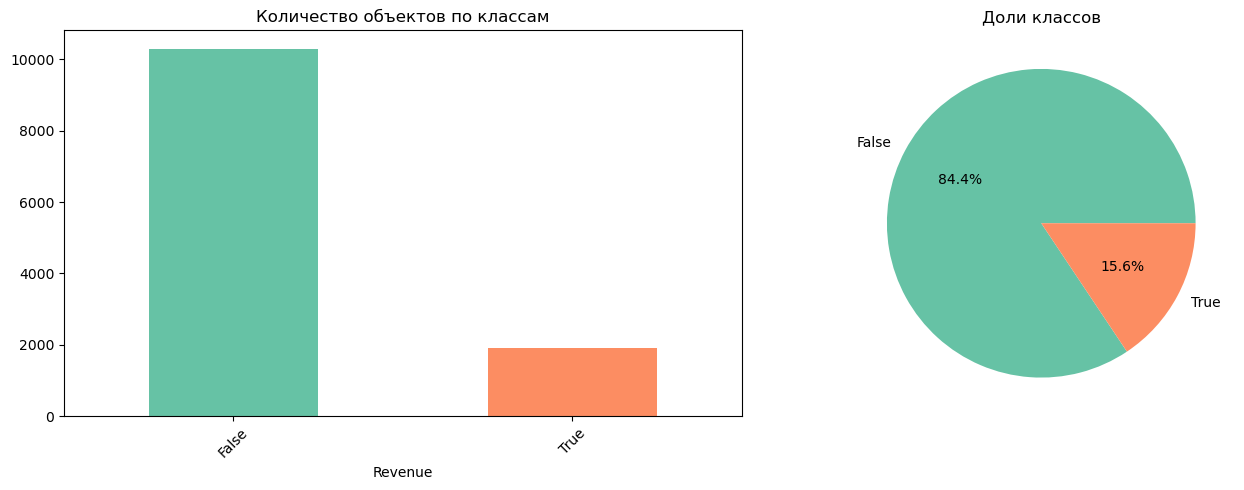

In [11]:
target_col = 'Revenue'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

data[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

In [12]:
data.Revenue.value_counts()

Revenue
False    10297
True      1908
Name: count, dtype: int64

Видим, что присутствует дисбаланс классов (84.4% у `False` и 15.6% у `True`). Так что при выборе метрик accuracy будет не единственной

Распределения признаков
-

Тип данных int или float не всегда означает, что это числовая колонка. Некоторые колонки, содержащие цифры, являются категориальными.  
Поэтому нужно вручную выписать числовые и категориальные колонки.

In [13]:
num_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated_Duration",
    "ProductRelated",
    "SpecialDay",
    "BounceRates",
    "ExitRates",
    "PageValues",
]

cat_cols = [
    "OperatingSystems",
    "Month",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

**Смотрим на распределение числовых колонк**

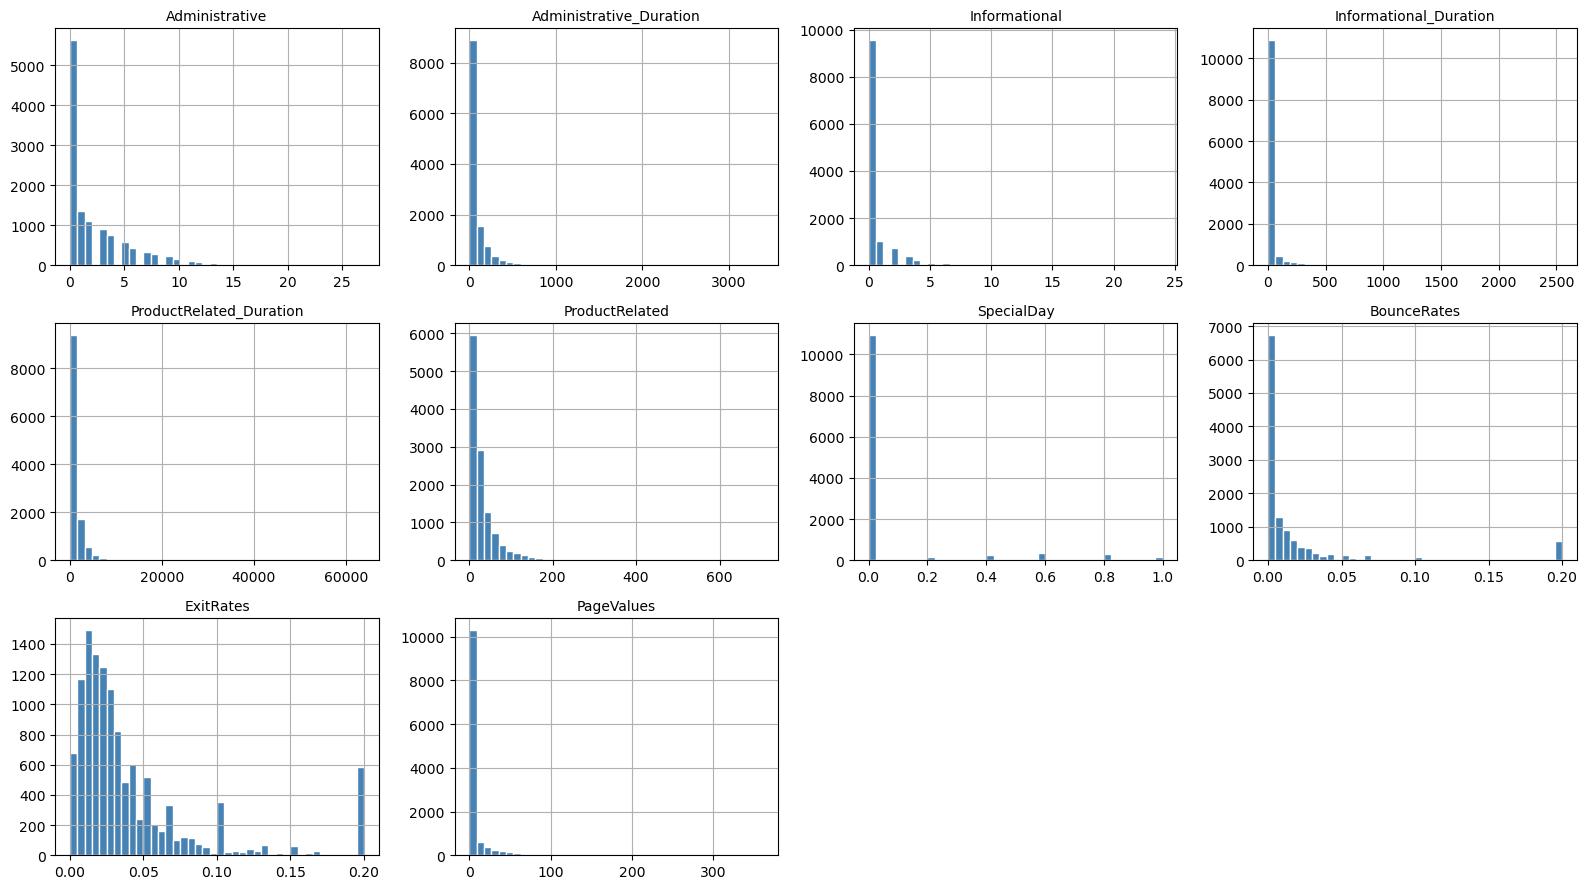

In [14]:
n_cols = len(num_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
data[num_cols].describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated_Duration,ProductRelated,SpecialDay,BounceRates,ExitRates,PageValues
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,1206.982457,32.045637,0.061942,0.020370,0.041466,5.949574
std,3.330436,177.491845,1.275617,141.424807,1919.601400,44.593649,0.199666,0.045255,0.046163,18.653671
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,193.000000,8.000000,0.000000,0.000000,0.014231,0.000000
50%,1.000000,9.000000,0.000000,0.000000,608.942857,18.000000,0.000000,0.002899,0.025000,0.000000
75%,4.000000,94.700000,0.000000,0.000000,1477.154762,38.000000,0.000000,0.016667,0.048529,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,63973.522230,705.000000,1.000000,0.200000,0.200000,361.763742


- По квартилям видно, что у некоторых колонок много нулей. Это может быть нормальным поведением пользователей, обработка таких значений не требуется

**Категориальные**

In [16]:
target = 'Revenue'
for col in cat_cols:
    print(f"\n\n========{col}=========")
    print("--- Value_counts ---")
    print(data[col].value_counts().sort_values(ascending=False))
    print("\n--- Связь с таргетом в % ---")
    print(pd.crosstab(data[col], data[target], normalize='index') * 100)



========OperatingSystems=========
--- Value_counts ---
OperatingSystems
2    6541
1    2549
3    2530
4     478
8      75
6      19
7       7
5       6
Name: count, dtype: int64

--- Связь с таргетом в % ---
Revenue               False      True 
OperatingSystems                      
1                 85.131424  14.868576
2                 82.342150  17.657850
3                 89.407115  10.592885
4                 82.217573  17.782427
5                 83.333333  16.666667
6                 89.473684  10.526316
7                 85.714286  14.285714
8                 77.333333  22.666667


========Month=========
--- Value_counts ---
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64

--- Связь с таргетом в % ---
Revenue      False      True 
Month                        
Aug      82.448037  17.551963
Dec      87.338804  12.661196
Feb      98.342541   1.657459
Jul      84.

--------------------------------
Выделяются TrafficType и Month:
- TrafficType: каналы 2, 7 и 20 дают конверсию 21–30%, тогда как каналы 13, 3 и 1 - менее 10%. Источник трафика сильно влияет на вероятность покупки.     
- Ноябрь (Nov) - месяц с пиком продаж; февраль наоборот обладает малым процентом revenue для сессий, заканчивающихся покупкой. Осень - много продаж, зима - спад.  

Корреляционная матрица
-

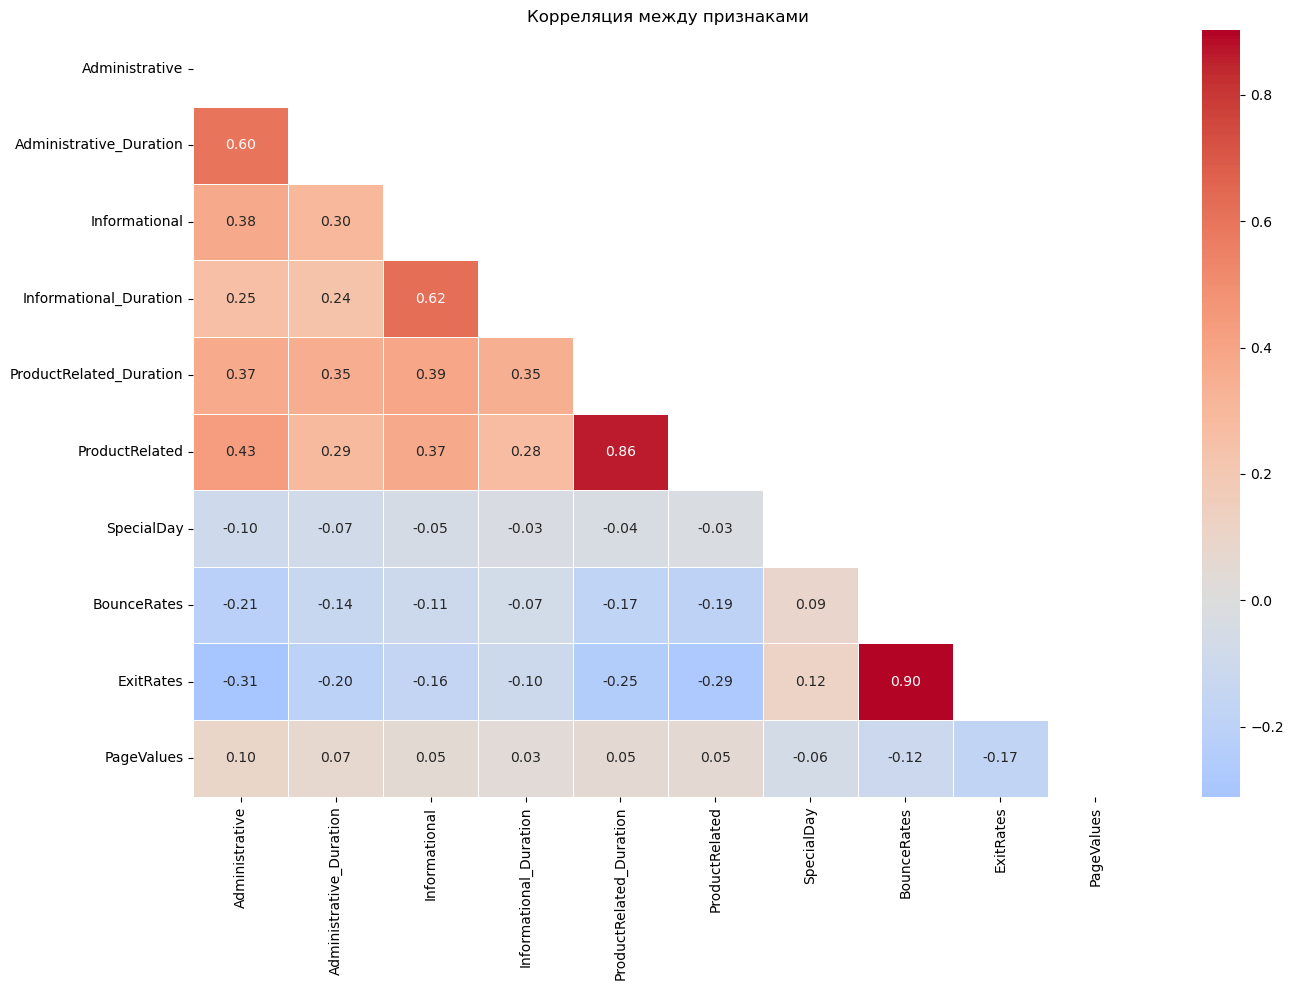

In [17]:
plt.figure(figsize=(14, 10))
corr = data[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

Из матрицы можем наблюдать пару колонок с довольно сильной корреляцией:
- `ProductRelated` и `ProductRelated_duration`  (0.86)
- `BounceRates` и `ExitRates`  (0.91)

Корреляция числовых колонок с таргетом

In [47]:
correlation = data[num_cols + ['Revenue']].corr()['Revenue'].drop('Revenue', axis=0).sort_values(ascending=False)
print(correlation)

PageValues                 0.491894
ProductRelated             0.156042
ProductRelated_Duration    0.150077
Administrative             0.136330
Informational              0.093626
Administrative_Duration    0.091768
Informational_Duration     0.069358
SpecialDay                -0.083601
BounceRates               -0.145091
ExitRates                 -0.204320
Name: Revenue, dtype: float64


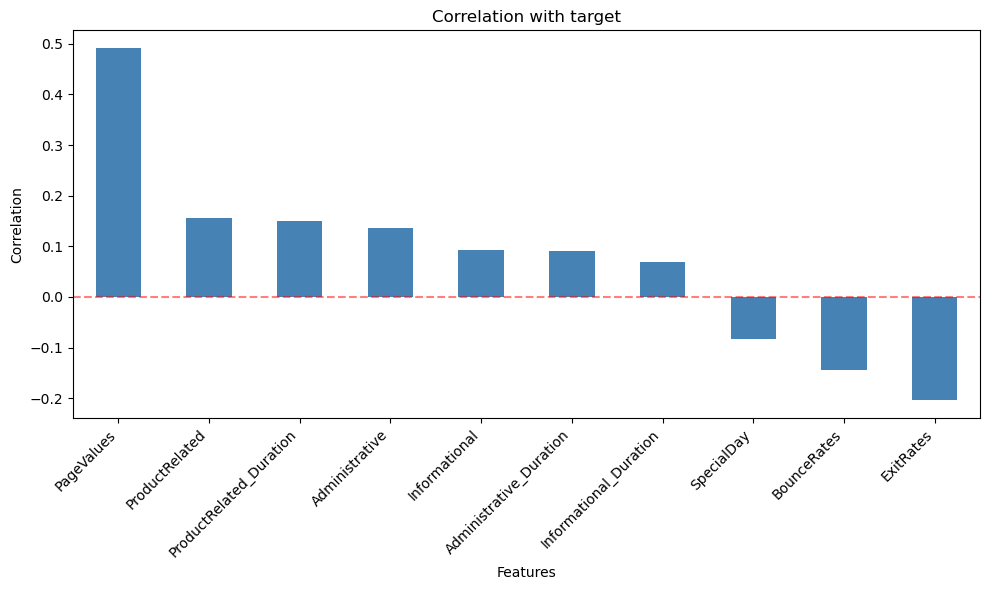

In [48]:
plt.figure(figsize=(10, 6))
correlation.plot(kind='bar', color='steelblue')
plt.title('Correlation with target')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

`PageValues` - признак с явной выраженной корреляцией с таргетом (~0.49). Возможно, это будет один из лучших признаков у моделей

Умеренная корреляция у `ProductRelated` (0.15), `ProductRelated_Duration` (0.15), `BounceRates`(-0.14) и `ExitRates` (-0.20)

Корреляция у `ExitRates` показывает, что частые выходы в среднем у тех пользователей, которые заканчивают сессию покупкой

Итоги EDA
-

- Пропусков нет; дубликаты есть (125) - были убраны
- Дисбаланс классов - доля положительного класса класса составляет ~15%
- Разные масштабы у числовых признаков, много нулей
- Есть коррелирующие признаки

## Гипотезы
- `Нормализация признаков` поможет улучшить `f1` `логистической регресси` не менее чем `на 0.1`
- `Дерево решений` покажет `f1` выше, чем `логистическая регрессия`, как минимум `на 0.05`, потому что деревья лучше работают с нелинейными зависимостями в данных
- Оптимизация параметров `RandomForest` через `GridSearch` незначительно улучшит `f1` модели (не более чем `на 0.05`) из-за того, что модель сама по себе хорошо работает из коробки (мало параметров, низкая чуствительность к шуму)
- Ограничение сложности `дерева решений` уменьшит переобучение модели 
- Отбор 10 лучших признаков через `SelectKBest` незначительно ухудшит `f1` `логистической регрессии`
- Среди первых пяти лучших признаков у `логистической регрессии` будут значения из `TrafficType` и `Month`

## Разбиение данных

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [20]:
from sklearn.metrics import make_scorer, accuracy_score, f1_score, roc_auc_score, recall_score, precision_score, \
                                    average_precision_score

In [21]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [23]:
SEED = 42

In [24]:
X, y = data.drop(columns=["Revenue"]), data.Revenue

In [25]:
print("X columns: ", X.columns.tolist())
print("y: ", y.name)

X columns:  ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
y:  Revenue


Обязательно учитываем баланс классов (stratify=y)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

In [27]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9153, 17)
X_test: (3052, 17)
y_train: (9153,)
y_test: (3052,)


In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

## Реализация baseline

**Первая гипотеза**: нормализация признаков поможет улучшить f1 логистической регресси не менее чем на 0.1

Реализуем baseline - логистическую регрессию.

In [29]:
# Продублируемся
num_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated_Duration",
    "ProductRelated",
    "SpecialDay",
    "BounceRates",
    "ExitRates",
    "PageValues",
]

cat_cols = [
    "OperatingSystems",
    "Month",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

Для проверки первой гипотезы нам нужно обучить логистическую регрессию с нормализацией числовых колонок и без нормализации и сравнить качество.

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), num_cols),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [31]:
# Для проверки первой гипотезы
preprocessor_without_scaler = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

Создаем две модели:
- С нормализацией признаков:

In [32]:
log_reg_pipline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1500, random_state=SEED)),
])

- Без нормализации:

In [33]:
log_reg_pipline_2 = Pipeline([
    ('preprocessor', preprocessor_without_scaler),
    ('model', LogisticRegression(max_iter=1500, random_state=SEED)),
])

Замеряем качество:

In [34]:
scorers = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'recall': 'recall',
    'precision': 'precision',
    'avg_precision': 'average_precision'
}

In [35]:
# Модель с нормализацией
cv_results_with_norm = cross_validate(
    estimator=log_reg_pipline,
    X=X_train,
    y=y_train,
    cv=5,
    scoring=scorers,
    return_train_score=False,
    n_jobs=-1
)

In [36]:
# Без нормализации
cv_results_without_norm = cross_validate(
    estimator=log_reg_pipline_2,
    X=X_train,
    y=y_train,
    cv=5,
    scoring=scorers,
    return_train_score=False,
    n_jobs=-1
)

Результаты

In [37]:
print("===== С нормализацией =====")
for metric in scorers.keys():
    scores = cv_results_with_norm[f'test_{metric}']
    print(f"{metric}: {scores.mean():.4f} (+- {scores.std() * 2:.4f})")

print("\n===== Без нормализации ====")
for metric in scorers.keys():
    scores = cv_results_without_norm[f'test_{metric}']
    print(f"{metric}: {scores.mean():.4f} (+- {scores.std() * 2:.4f})")

===== С нормализацией =====
accuracy: 0.8817 (+- 0.0075)
f1: 0.4951 (+- 0.0496)
roc_auc: 0.8898 (+- 0.0262)
recall: 0.3718 (+- 0.0519)
precision: 0.7428 (+- 0.0314)
avg_precision: 0.6345 (+- 0.0606)

===== Без нормализации ====
accuracy: 0.8437 (+- 0.0011)
f1: 0.0041 (+- 0.0111)
roc_auc: 0.6841 (+- 0.0229)
recall: 0.0021 (+- 0.0056)
precision: 0.2000 (+- 0.5333)
avg_precision: 0.2662 (+- 0.0331)


Вывод по первой гипотезе
-

**Первая гипотеза подтвердилась**. Масштабирование признаков улучшило F1 логистической регрессии с 0.00 до 0.495 (прирост > 0.1). Без нормализации модель не обучается из-за разных масштабов признаков и предсказывает только большинственный класс. Дополнительно наблюдается улучшение ROC-AUC с 0.68 до 0.89.

## Добавляем модели

**Вторая гипотеза**: дерево решений покажет f1 выше, чем логистическая регрессия, как минимум на 0.05, потому что деревья лучше работают с нелинейными зависимостями в данных

Дерево решений

In [145]:
one_tree_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=SEED))
    ]
)

Случайный лес

In [146]:
rf_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=SEED))
    ]
)

In [147]:
models = {
    "LogisticRegression": log_reg_pipline,
    "DecisionTree": one_tree_pipeline,
    "RandomForest": rf_pipeline
}

In [148]:
cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scorers, n_jobs=-1, 
                            return_train_score=True)
    row = {'model': name}
    
    # Test метрики
    for metric in scorers.keys():
        row[f'val_{metric}'] = scores[f'test_{metric}'].mean()
    
    # Train метрики
    for metric in scorers.keys():
        row[f'train_{metric}'] = scores[f'train_{metric}'].mean()
    
    cv_rows.append(row)

results = pd.DataFrame(cv_rows).set_index('model')
display(results.T.round(3))

model,LogisticRegression,DecisionTree,RandomForest
val_accuracy,0.881,0.863,0.899
val_f1,0.492,0.568,0.613
val_roc_auc,0.889,0.745,0.921
val_recall,0.369,0.574,0.511
val_precision,0.740,0.563,0.767
val_avg_precision,0.636,0.390,0.732
train_accuracy,0.883,1.000,1.000
train_f1,0.502,1.000,1.000
train_roc_auc,0.898,1.000,1.000
train_recall,0.378,1.000,1.000


`DecisionTree` и `RandomForest` переобучились на обучающей выборке (трейн метрики равны 1). Однако `RandomForest` компенсирует это ансамблированием, показывая лучший F1 на валидации (0.613), в то время как `DecisionTree` значительно проседает (0.568). `LogisticRegression` стабильна, но уступает в качестве (0.492).

Вывод по второй гипотезе
-

**Гипотеза подтвердилась** 
- LogisticRegression: F1 = 0.492
- DecisionTree: F1 = 0.568
- Разница: +0.076 (при ожидаемом пороге 0.05)
- Причина: деревья решений лучше работают с нелинейными зависимостями в данных.

## Подбор гиперпараметров для RandomForest

**Третья гипотеза**: оптимизация параметров RandomForest через GridSearch незначительно улучшит f1 модели (не более чем на 0.05) из-за того, что модель сама по себе хорошо работает из коробки (мало параметров, низкая чуствительность к шуму)

In [149]:
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 8, 10, 12, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [154]:
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    return_train_score=True,
    cv=cv,
    n_jobs=-1,
    refit=True
)

In [155]:
rf_grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         StandardScaler(),
                                                                         ['Administrative',
                                                                          'Administrative_Duration',
                                                                          'Informational',
                                                                          'Informational_Duration',
                                                                          'ProductRelated_Duration',
                                                                          'ProductRelated',
                                                                          'SpecialDay',
                                                                          'BounceRates',
                                                                          'ExitRates',
                                                                          'PageVal...
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['OperatingSystems',
                                                                          'Month',
                                                                          'Browser',
                                                                          'Region',
                                                                          'TrafficType',
                                                                          'VisitorType',
                                                                          'Weekend'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 8, 10, 12, 15, None],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='f1')

In [158]:
index_of_best_rf = rf_grid_search.best_index_

In [160]:
tuned_rf_train_f1 = rf_grid_search.cv_results_["mean_train_score"][index_of_best_rf]
tuned_rf_val_f1 = rf_grid_search.cv_results_["mean_test_score"][index_of_best_rf]

In [161]:
print("Лучший val f1:", tuned_rf_val_f1)
print("Лучший train f1:", tuned_rf_train_f1)

Лучший val f1: 0.6284900001019945
Лучший train f1: 0.8723542877185715


In [157]:
best_rf_params = rf_grid_search.best_params_
print("Лучшие параметры: ", best_rf_params)

Лучшие параметры:  {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}


Вывод по третьей гипотезе
-

**Гипотеза подтвердилась**. Тюнинг гиперпараметров RandomForest (без учета балансировки классов) дал незначительное улучшение F1 с 0.613 до 0.628 (+0.015). Это подтверждает, что RandomForest устойчив к выбору гиперпараметров и хорошо работает "из коробки". 
Базовая модель уже показывает достойный результат, а настройка параметров дает лишь небольшой прирост качества.

## Ограничение сложности дерева решений

Ограничить сложность дерева можно с помощью подбора оптимальных гиперпараметров

In [98]:
dt_param_grid = {
    'model__max_depth': [5, 8, 10, 12, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [111]:
dt_grid_search = GridSearchCV(
    estimator=one_tree_pipeline,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=cv,
    return_train_score=True,
    n_jobs=-1,
    refit=True
)

In [112]:
dt_grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         StandardScaler(),
                                                                         ['Administrative',
                                                                          'Administrative_Duration',
                                                                          'Informational',
                                                                          'Informational_Duration',
                                                                          'ProductRelated_Duration',
                                                                          'ProductRelated',
                                                                          'SpecialDay',
                                                                          'BounceRates',
                                                                          'ExitRates',
                                                                          'PageVal...
                                                                        ('categorical',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['OperatingSystems',
                                                                          'Month',
                                                                          'Browser',
                                                                          'Region',
                                                                          'TrafficType',
                                                                          'VisitorType',
                                                                          'Weekend'])])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 8, 10, 12, 15],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10]},
             return_train_score=True, scoring='f1')

In [162]:
print("Лучший train f1:", dt_grid_search.best_score_)

Лучший train f1: 0.6455338393962962


In [165]:
best_dt_params = dt_grid_search.best_params_
print("Лучшие параметры: ", best_dt_params)

Лучшие параметры:  {'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2}


Сравнение нового дерева со старым
-

In [117]:
index_of_best_tree = dt_grid_search.best_index_

In [119]:
tuned_dt_train_f1 = dt_grid_search.cv_results_["mean_train_score"][index_of_best_tree]
tuned_dt_val_f1 = dt_grid_search.cv_results_["mean_test_score"][index_of_best_tree]

In [124]:
comparison = pd.DataFrame({
    "Model": ["Base Decision Tree", "Tuned Decision Tree"],
    "Validation F1": [results.loc['DecisionTree', 'val_f1'], tuned_dt_train_f1,],
    "Train F1": [results.loc['DecisionTree', 'train_f1'], tuned_dt_val_f1]
})

In [125]:
comparison

,Model,Validation F1,Train F1
0,Base Decision Tree,0.567502,1.000000
1,Tuned Decision Tree,0.694327,0.645534


In [110]:
results.loc['DecisionTree', ['val_f1', 'train_f1']]

val_f1      0.567502
train_f1    1.000000
Name: DecisionTree, dtype: float64

Вывод по четвертой гипотезе
-

Гипотеза подтвердилась. Ограничение сложности дерева (max depth=5, min samples leaf=2) устранило переобучение: Val F1 вырос с 0.568 до 0.694, а Train F1 снизился с 1.000 до 0.646. Модель стала проще, но лучше обобщается.

---

Вспомним метрики RandomForest после подбора параметров:
- Лучший val f1: 0.6284900001019945
- Лучший train f1: 0.8723542877185715

Можно увидеть, что после тюнинга гиперпараметров дерево решений (Decision Tree) неожиданно обошло случайный лес (Random Forest) по валидационному F1 (0.694 против 0.628).

Основная причина - Random Forest переобучился: разрыв между тренировочным и валидационным F1 составил 0.244 (0.872 vs 0.628), тогда как у дерева решений переобучения нет (Train F1 = 0.646, Val F1 = 0.694, разница отрицательная).

Вероятно, глубокие деревья в ансамбле не смогли полностью компенсировать это усреднением, в то время как одно дерево с ограниченной глубиной (5) нашло оптимальный баланс между сложностью и обобщением.

## Отбор признаков у логистической регрессии через SelectKBest

In [49]:
from sklearn.feature_selection import SelectKBest, f_classif

In [79]:
logreg_kbest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('kbest_model', SelectKBest(f_classif, k=10)),
    ('model', LogisticRegression(max_iter=1500, random_state=SEED))
])

In [80]:
logreg_kbest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated_Duration',
                                                   'ProductRelated',
                                                   'SpecialDay', 'BounceRates',
                                                   'ExitRates', 'PageValues']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['OperatingSystems', 'Month',
                                                   'Browser', 'Region',
                                                   'TrafficType', 'VisitorType',
                                                   'Weekend'])])),
                ('kbest_model', SelectKBest()),
                ('model', LogisticRegression(max_iter=1500, random_state=42))])

In [81]:
selector = logreg_kbest_pipeline.named_steps['kbest_model']
scores = selector.scores_

In [82]:
feature_names = (
    logreg_kbest_pipeline.named_steps['preprocessor'].get_feature_names_out()
)

In [83]:
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'score': selector.scores_,
    'selected': selector.get_support()
}).sort_values('score', ascending=False)

In [84]:
selected_features = feature_importance[feature_importance['selected']]

In [85]:
selected_features

,feature,score,selected
9,numeric__PageValues,2804.784729,True
8,numeric__ExitRates,406.179469,True
25,categorical__Month_Nov,206.362592,True
7,numeric__BounceRates,197.492009,True
5,numeric__ProductRelated,195.625151,True
4,numeric__ProductRelated_Duration,177.471490,True
0,numeric__Administrative,169.147981,True
51,categorical__TrafficType_2,113.670855,True
71,categorical__VisitorType_Returning_Visitor,83.220921,True
69,categorical__VisitorType_New_Visitor,78.148510,True


In [87]:
kbest_f1 = cross_validate(logreg_kbest_pipeline, X_train, y_train, cv=cv,
                              scoring='f1', n_jobs=-1)['test_score']

In [91]:
print("f1 после отбора 10 признаков: ", kbest_f1.mean().round(3))

f1 после отбора 10 признаков:  0.497


**Результат:**
- F1 до отбора: 0.492
- F1 после отбора: 0.497
- Изменение: +0.005

Выводы
-

- **Пятая гипотеза не подтвердилась.** Вопреки ожиданиям, отбор 10 лучших признаков не ухудшил `f1`, а наоборот - незначительно улучшил его `с 0.492 до 0.497`. Это говорит о том, что `SelectKBest` успешно отсеял шумовые признаки, которые мешали модели, и оставил только информативные.

- **шестая гипотеза подтвердилась частично.** `Month_Nov` вошел в топ-5 признаков (3-е место), что подтверждает сезонность: в ноябре сессий, заканчивающихся покупками, больше. `TrafficType` не попал в топ-5, но оказался на 8-м месте в топ-10 (TrafficType_2). Это говорит о том, что источник трафика важен, но уступает по силе таким признакам, как PageValues, ExitRates и BounceRates.


## Выбор финальной модели

Обычное дерево решений с подбором гиперпараметров в среднем показал лучший validation f1 (0.69) при train f1 = 0.65.  
Разница между val f1 и train f1 небольшая (~0.04), поэтому эта модель и будет выбрана как финальная.  

In [190]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, precision_score, \
                                    average_precision_score, confusion_matrix, ConfusionMatrixDisplay, \
                                    classification_report

In [166]:
print("Параметры финальной модели: " )
for param, value in best_dt_params.items():
    print(f"{param}: {value}")

Параметры финальной модели: 
model__max_depth: 5
model__min_samples_leaf: 2
model__min_samples_split: 2


In [167]:
final_model = dt_grid_search.best_estimator_

In [168]:
y_pred_test = final_model.predict(X_test)
y_prob_test = final_model.predict_proba(X_test)[:, 1]

In [174]:
test_f1 = f1_score(y_test, y_pred_test, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_prob_test)
test_precision = precision_score(y_test, y_pred_test, zero_division=0)
test_recall = recall_score(y_test, y_pred_test, zero_division=0)
test_accuracy = accuracy_score(y_test, y_pred_test)
test_avg_precision = average_precision_score(y_test, y_prob_test)

In [175]:
test_metrics = pd.DataFrame({
    "Metric": [
        "f1",
        "roc-auc",
        "precision",
        "recall",
        "accuracy",
        "average precision"
    ],
    "Value": [
        test_f1,
        test_roc_auc,
        test_precision,
        test_recall,
        test_accuracy,
        test_avg_precision
    ]
})

In [178]:
test_metrics.round(3)

,Metric,Value
0,f1,0.656
1,roc-auc,0.925
2,precision,0.710
3,recall,0.610
4,accuracy,0.900
5,average precision,0.695


ROC-AUC = 0.925 - модель отлично разделяет классы и с высокой вероятностью присваивает более высокие оценки покупкам, чем не-покупкам.

Precision = 0.710 - из всех клиентов, которых модель предсказала как покупателей, 71% действительно совершили покупку.

Recall = 0.610 - модель правильно обнаружила 61% всех реальных покупателей, пропустив 39%

In [195]:
print(classification_report(y_test, y_pred_test, target_names=["False", "True"]))
print(
    """
    Где:
        - True - сессия пользователя закончилась покупкой
        - False - сессия без покупки
    """
)

              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2575
        True       0.71      0.61      0.66       477

    accuracy                           0.90      3052
   macro avg       0.82      0.78      0.80      3052
weighted avg       0.90      0.90      0.90      3052


    Где:
        - True - сессия пользователя закончилась покупкой
        - False - сессия без покупки
    


Матрица ошибок
-

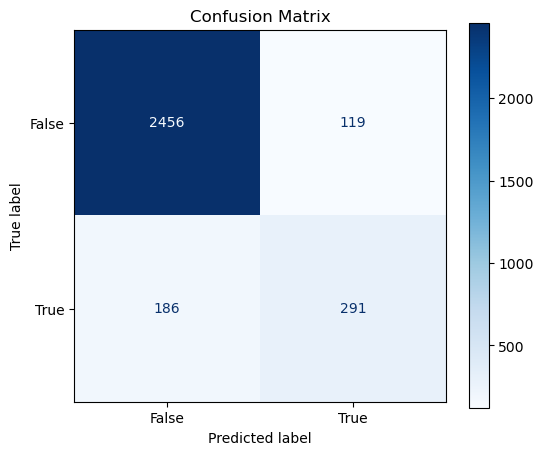

In [186]:
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['False', 'True'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

Из матрицы ошибок выделяем:
- **TN** = 2456 правильно найденных моделью положительных классов
- **TP** = 291 правильно предсказанных положительных классов как положительный
- **FP** = 119 ложных срабатываний
- **FN** = 186 пропусков положительного класса

Основная проблема - FN = 186 (пропущенные покупатели), что важнее для бизнеса, чем FP = 119 (ложные срабатывания), так как лучше, например, предложить скидку лишнему пользователю, чем упустить реального клиента.

FN можно отрегулировать, поставив порог классификации пониже (в ущерб FP)

## Выводы по гипотезам

Первая гипотеза
-

Нормализация признаков логистической регресии улучшит f1 не менее чем на 0.1

*Гипотеза подтвердилась*. Масштабирование признаков улучшило F1 логистической регрессии с 0.00 до 0.495 (прирост > 0.1). Без нормализации модель не обучается из-за разных масштабов признаков и предсказывает только большинственный класс. Дополнительно наблюдается улучшение ROC-AUC с 0.68 до 0.89.

Вторая гипотеза
-

Дерево решений покажет f1 выше, чем логистическая регрессия, как минимум на 0.05

*Гипотеза подтвердилась*. F1 логистической регрессии = 0.492, а f1 дерева = 0.568. Разница: +0.076 из-за нелинейности деревьев.

Третья гипотеза
-

Оптимизация параметров RandomForest через GridSearch незначительно улучшит f1 модели (не более чем на 0.05) из-за того, что модель сама по себе хорошо работает из коробки (мало параметров, низкая чуствительность к шуму)

*Гипотеза подтвердилась*. Тюнинг гиперпараметров RandomForest (без учета балансировки классов) дал незначительное улучшение F1 с 0.613 до 0.628 (+0.015). Это подтверждает, что RandomForest устойчив к выбору гиперпараметров и хорошо работает "из коробки". Базовая модель уже показывает достойный результат, а настройка параметров дает лишь небольшой прирост качества.

Четвертая гипотеза
-

Ограничение сложности дерева решений уменьшит переобучение модели.

*Гипотеза подтвердилась*. Ограничение сложности дерева решений (max_depth=5, min_samples_leaf=2, min_samples_split=2) полностью устранило переобучение и значительно улучшило качество обобщения модели.

Пятая гипотеза
-

*Гипотеза не подтвердилась.* Отбор 10 лучших признаков не ухудшил `f1`, а наоборот - незначительно улучшил его `с 0.492 до 0.497`. Это говорит о том, что `SelectKBest` успешно отсеял шумовые признаки, которые мешали модели, и оставил только информативные.

Шестая гипотеза
-

*Шестая гипотеза подтвердилась частично.* `Month_Nov` вошел в топ-5 признаков (3-е место), что подтверждает сезонность: в ноябре сессий, заканчивающихся покупками, больше. `TrafficType` не попал в топ-5, но оказался на 8-м месте в топ-10 (TrafficType_2). Это говорит о том, что источник трафика важен, но уступает по силе таким признакам, как PageValues, ExitRates и BounceRates.